# CSE422 Machine Learning Project
---
## Predicting Student Anxiety, Stress and Depression Levels
**Course:** CSE422 - Artificial Intelligence Lab

**Dataset:** Student Mental Health Survey

**Authors:** Ridita Katha, Paromita Rasheed

**BRAC University**

---

## 1. Introduction
This project predicts a university student's **Anxiety level**, **Stress level**
and **Depression level** from survey answers about academic pressure.

Screening normally needs a counsellor to score a full questionnaire by hand. If
the levels can be predicted from background details and related symptoms, a
university could flag students who may need support much sooner.

The dataset uses three standard scales: GAD-7 for anxiety, PSS-10 for stress
and PHQ-9 for depression. Each has its own questions, a total score, and a level
label derived from that total. These are survey-based screening levels, not
clinical diagnoses.

## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split # divides the data into training and testing sets
from sklearn.preprocessing import  StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans # Unsupervised Learning
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, classification_report, adjusted_rand_score) # evaluate the models
# Neural Network
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
SEED = 42
np.random.seed(SEED)

---
## 2. Dataset Description

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

CSV_PATH = '/content/drive/MyDrive/Colab Notebooks/Depression Data.csv'
if not os.path.exists(CSV_PATH):
    CSV_PATH = 'Depression Data.csv'

df = pd.read_csv(CSV_PATH)

# The survey questions are used as column names and are far too long to plot, so we rename them to the short codes each scale normally uses.
anx_items = [f'GAD{i}' for i in range(1, 8)]     # 7 anxiety questions
str_items = [f'PSS{i}' for i in range(1, 11)]    # 10 stress questions
dep_items = [f'PHQ{i}' for i in range(1, 10)]    # 9 depression questions
demo = ['Age', 'Gender', 'Academic_Year', 'CGPA', 'Scholarship']

df.columns = (demo + anx_items + ['Anxiety_Value', 'Anxiety_Label'] + str_items + ['Stress_Value', 'Stress_Label'] + dep_items + ['Depression_Value', 'Depression_Label'])

TARGETS = ['Anxiety_Label', 'Stress_Label', 'Depression_Label']

print(f"Data points : {df.shape[0]}")
print(f"Columns     : {df.shape[1]}")
print(f"Missing     : {df.isnull().sum().sum()}")
print()
print("This is a CLASSIFICATION problem: each target is a discrete level")
print("(a text label such as 'Mild Anxiety'), not a continuous number.")
print()
print("Column groups:")
print(f"  Demographic        : {demo}")
print(f"  Anxiety (GAD-7)    : 7 questions  -> Anxiety_Value -> Anxiety_Label")
print(f"  Stress (PSS-10)    : 10 questions -> Stress_Value -> Stress_Label")
print(f"  Depression (PHQ-9) : 9 questions  -> Depression_Value -> Depression_Label")
print()
print("Feature types:")
for col in demo:
    print(f"  {col:<16} Categorical")
print("  All GAD / PSS / PHQ question scores and the three totals: Quantitative")
print()
print("Target classes:")
for t in TARGETS:
    print(f"  {t:<20} {df[t].nunique()} classes -> {sorted(df[t].unique())}")

df.head()

Data points : 1977
Columns     : 37
Missing     : 6

This is a CLASSIFICATION problem: each target is a discrete level
(a text label such as 'Mild Anxiety'), not a continuous number.

Column groups:
  Demographic        : ['Age', 'Gender', 'Academic_Year', 'CGPA', 'Scholarship']
  Anxiety (GAD-7)    : 7 questions  -> Anxiety_Value -> Anxiety_Label
  Stress (PSS-10)    : 10 questions -> Stress_Value -> Stress_Label
  Depression (PHQ-9) : 9 questions  -> Depression_Value -> Depression_Label

Feature types:
  Age              Categorical
  Gender           Categorical
  Academic_Year    Categorical
  CGPA             Categorical
  Scholarship      Categorical
  All GAD / PSS / PHQ question scores and the three totals: Quantitative

Target classes:
  Anxiety_Label        4 classes -> ['Mild Anxiety', 'Minimal Anxiety', 'Moderate Anxiety', 'Severe Anxiety']
  Stress_Label         3 classes -> ['High Perceived Stress', 'Low Stress', 'Moderate Stress']
  Depression_Label     6 classes -> ['Mi

,Age,Gender,Academic_Year,CGPA,Scholarship,GAD1,GAD2,GAD3,GAD4,GAD5,...,PHQ2,PHQ3,PHQ4,PHQ5,PHQ6,PHQ7,PHQ8,PHQ9,Depression_Value,Depression_Label
0,18-22,Female,Fourth Year or Equivalent,2.50 - 2.99,No,1,1,1,2,2,...,2,1,1,2,1,1,1,1,11,Moderate Depression
1,18-22,Male,First Year or Equivalent,3.80 - 4.00,No,2,2,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
2,18-22,Male,First Year or Equivalent,3.00 - 3.39,No,2,1,1,0,2,...,0,2,3,2,2,2,2,1,16,Moderately Severe Depression
3,18-22,Male,First Year or Equivalent,3.40 - 3.79,No,2,1,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression
4,18-22,Male,First Year or Equivalent,3.40 - 3.79,No,1,1,1,1,1,...,1,1,1,1,1,1,1,1,9,Mild Depression


### 2.1 How the Labels Are Built

Each `_Value` column is the **sum** of its own questions, and each `_Label` is a
threshold cut of that value. So a scale's questions give away that scale's
label. They have to be removed from the features, otherwise the model is only
re-adding numbers instead of learning.

In [ ]:
print("Is each Value column simply the sum of its questions?")
for items, value in [(anx_items, 'Anxiety_Value'),
                     (str_items, 'Stress_Value'),
                     (dep_items, 'Depression_Value')]:
    match = (df[items].sum(axis=1) == df[value]).mean() * 100
    print(f"  {value:<18} matches in {match:.1f}% of rows")

print()
print("Score range for each Depression level:")
print(df.groupby('Depression_Label')['Depression_Value'].agg(['min', 'max']).to_string())

print()
print("So when a label is the target, its own questions and its own Value are dropped. The other two scales are kept, because predicting depression from anxiety and stress answers is a genuine prediction.")

Is each Value column simply the sum of its questions?
  Anxiety_Value      matches in 100.0% of rows
  Stress_Value       matches in 100.0% of rows
  Depression_Value   matches in 100.0% of rows

Score range for each Depression level:
                              min  max
Depression_Label                      
Mild Depression                 5    9
Minimal Depression              1    4
Moderate Depression            10   14
Moderately Severe Depression   15   19
No Depression                   0    0
Severe Depression              20   27

So when a label is the target, its own questions and its own Value are dropped. The other two scales are kept, because predicting depression from anxiety and stress answers is a genuine prediction.


### 2.2 Correlation Heatmap

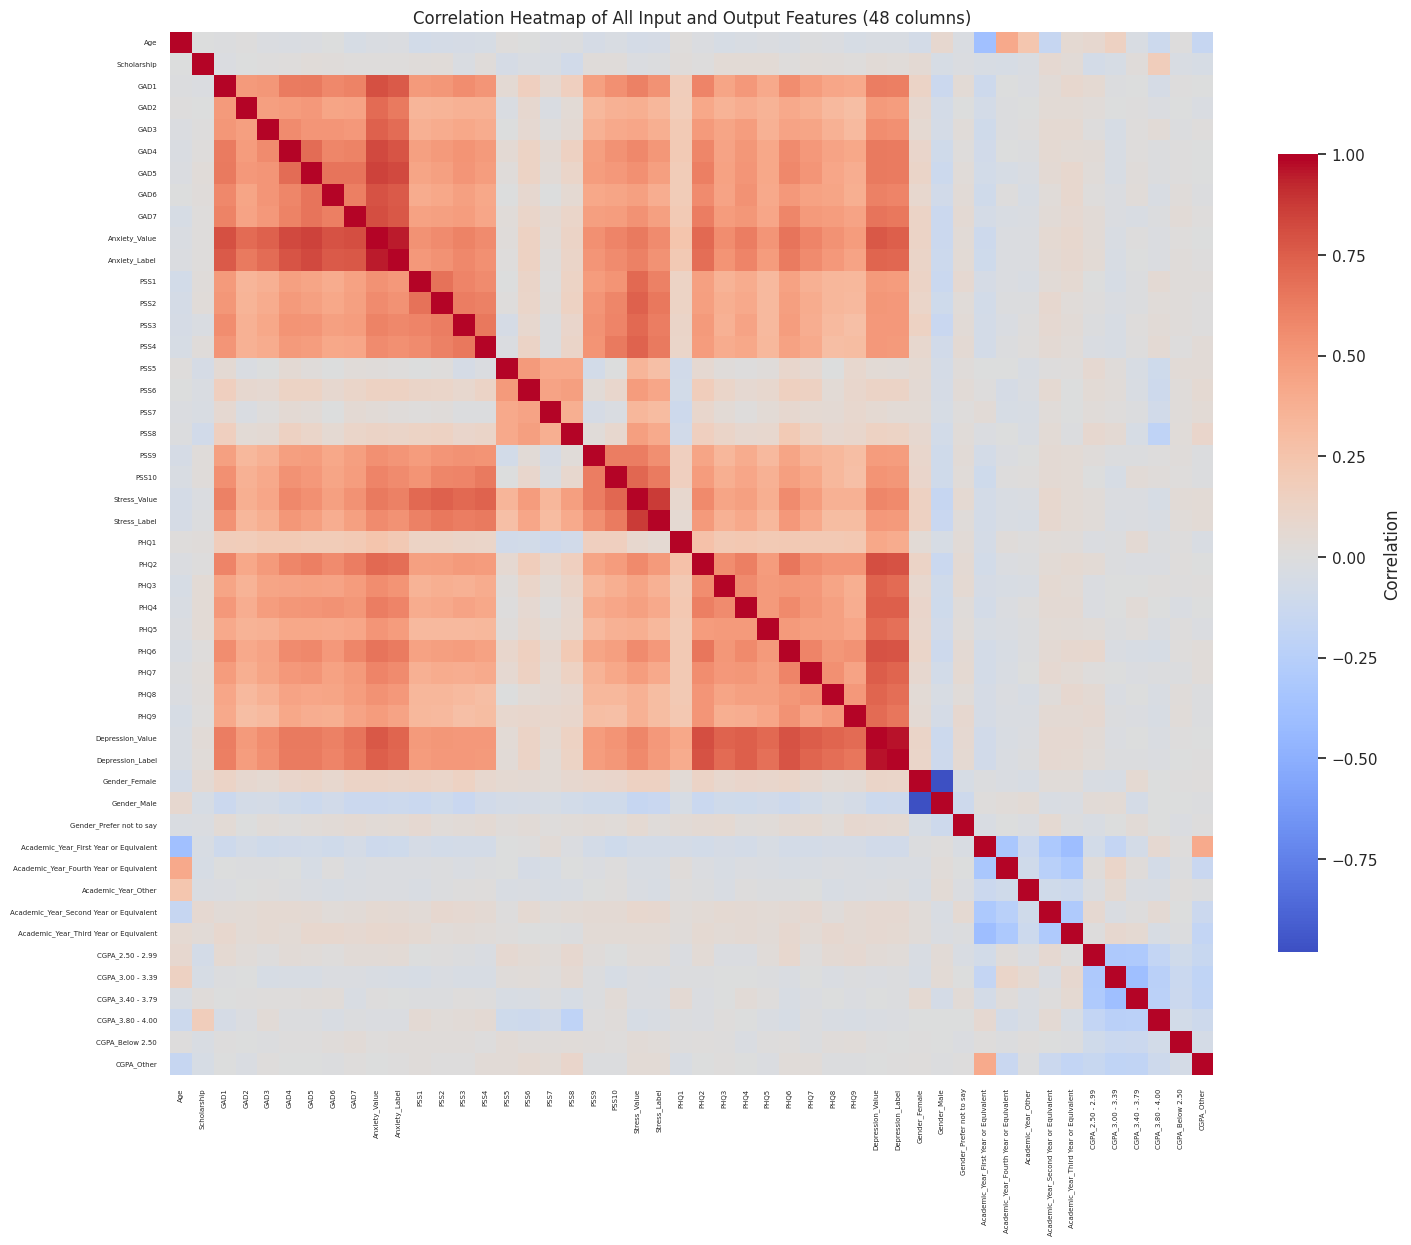

Heatmap covers 48 columns after one-hot encoding.

Correlation of every feature with the three targets:
                                         Anxiety_Label  Stress_Label  Depression_Label
Age                                             -0.020        -0.057            -0.036
Scholarship                                      0.013        -0.013             0.027
GAD1                                             0.766         0.532             0.615
GAD2                                             0.640         0.340             0.475
GAD3                                             0.691         0.384             0.540
GAD4                                             0.790         0.508             0.633
GAD5                                             0.822         0.473             0.632
GAD6                                             0.767         0.395             0.595
GAD7                                             0.771         0.463             0.651
Anxiety_Value             

In [ ]:

ORDERS = {
    'Age': ['Below 18', '18-22', '23-26', '27-30', 'Above 30'],
    'Anxiety_Label': ['Minimal Anxiety', 'Mild Anxiety', 'Moderate Anxiety', 'Severe Anxiety'],
    'Stress_Label': ['Low Stress', 'Moderate Stress', 'High Perceived Stress'],
    'Depression_Label': ['No Depression', 'Minimal Depression', 'Mild Depression', 'Moderate Depression', 'Moderately Severe Depression', 'Severe Depression'],
    }
ONEHOT = ['Gender', 'Academic_Year', 'CGPA']

df_corr = df.copy()
for col, order in ORDERS.items():
    df_corr[col] = df_corr[col].map({v: i for i, v in enumerate(order)})
df_corr['Scholarship'] = df_corr['Scholarship'].map({'No': 0, 'Yes': 1})
df_corr = pd.concat(
    [df_corr.drop(columns=ONEHOT),
     pd.get_dummies(df_corr[ONEHOT], columns=ONEHOT).astype(int)], axis=1) # Creates one-hot columns

corr = df_corr.corr() # calculates Pearson correlation between every pair of numerical columns

plt.figure(figsize=(15, 13))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, xticklabels=True, yticklabels=True, cbar_kws={'shrink': 0.7, 'label': 'Correlation'})
plt.xticks(fontsize=5)
plt.yticks(fontsize=5)
plt.title(f'Correlation Heatmap of All Input and Output Features '
          f'({corr.shape[0]} columns)')
plt.tight_layout()
plt.show()

print(f"Heatmap covers {corr.shape[0]} columns after one-hot encoding.")
print()
print("Correlation of every feature with the three targets:")
print(corr[TARGETS].drop(index=TARGETS).round(3).to_string())

print(" Red = +ve  Blue = -ve  Gray = near 0  neutral colour = 0")


### 2.3 Imbalanced Dataset Check

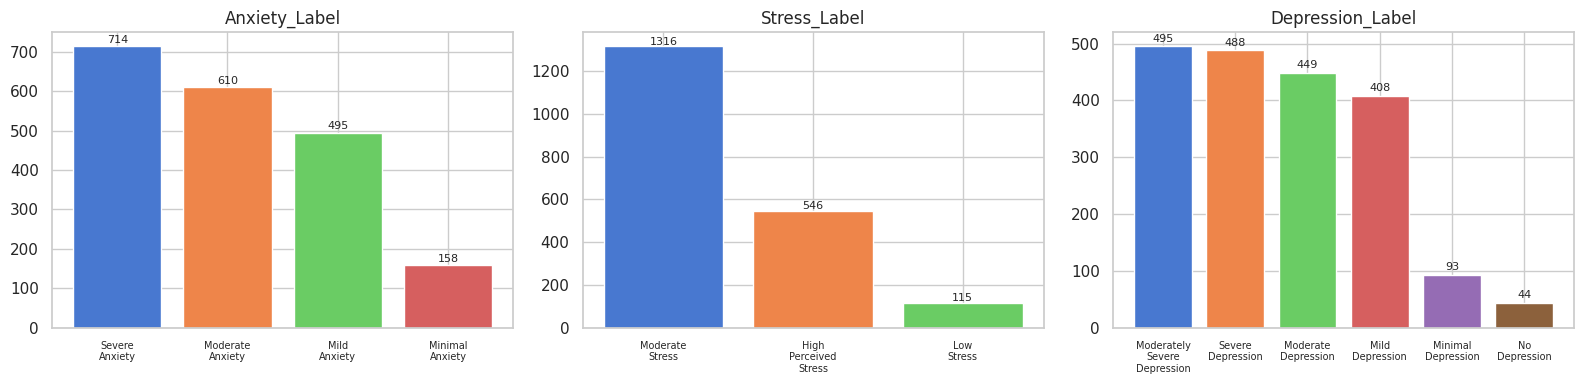

Anxiety_Label        4 classes, imbalance ratio 4.5 : 1, baseline 0.3612
Stress_Label         3 classes, imbalance ratio 11.4 : 1, baseline 0.6657
Depression_Label     6 classes, imbalance ratio 11.2 : 1, baseline 0.2504


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, t in zip(axes, TARGETS):
    counts = df[t].value_counts()
    ax.bar(range(len(counts)), counts.values, color=sns.color_palette('muted'))
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels([c.replace(' ', '\n') for c in counts.index], fontsize=7)
    ax.set_title(t)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 8, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

for t in TARGETS:
    counts = df[t].value_counts()
    print(f"{t:<20} {len(counts)} classes, imbalance ratio "
          f"{counts.max() / counts.min():.1f} : 1, baseline {counts.max() / len(df):.4f}")


### 2.4 Exploratory Data Analysis

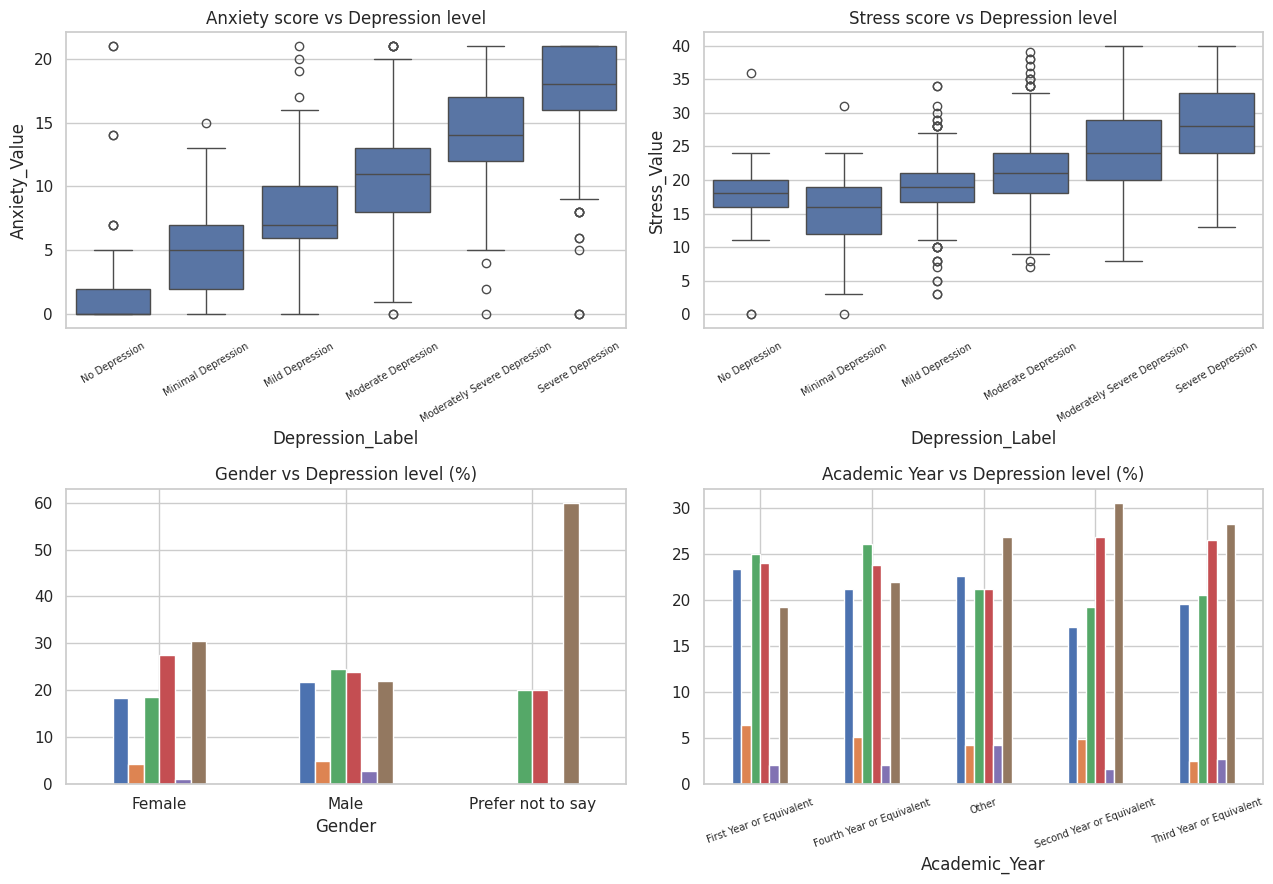

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
order = df.groupby('Depression_Label')['Depression_Value'].mean().sort_values().index

# 1. Anxiety total vs depression level
sns.boxplot(data=df, x='Depression_Label', y='Anxiety_Value', order=order, ax=axes[0, 0])
axes[0, 0].set_title('Anxiety score vs Depression level')
axes[0, 0].tick_params(axis='x', rotation=30, labelsize=7)

# 2. Stress total vs depression level
sns.boxplot(data=df, x='Depression_Label', y='Stress_Value', order=order, ax=axes[0, 1])
axes[0, 1].set_title('Stress score vs Depression level')
axes[0, 1].tick_params(axis='x', rotation=30, labelsize=7)

# 3. Gender vs depression level, as % within each gender
pd.crosstab(df['Gender'], df['Depression_Label'], normalize='index').mul(100) \
  .plot(kind='bar', ax=axes[1, 0], legend=False)
axes[1, 0].set_title('Gender vs Depression level (%)')
axes[1, 0].tick_params(axis='x', rotation=0)

# 4. Academic year vs depression level
pd.crosstab(df['Academic_Year'], df['Depression_Label'], normalize='index').mul(100) \
  .plot(kind='bar', ax=axes[1, 1], legend=False)
axes[1, 1].set_title('Academic Year vs Depression level (%)')
axes[1, 1].tick_params(axis='x', rotation=20, labelsize=7)

plt.tight_layout()
plt.show()


---
## 3. Dataset Pre-processing

Three problems, each with its solution.

**Problem 1: Missing values**

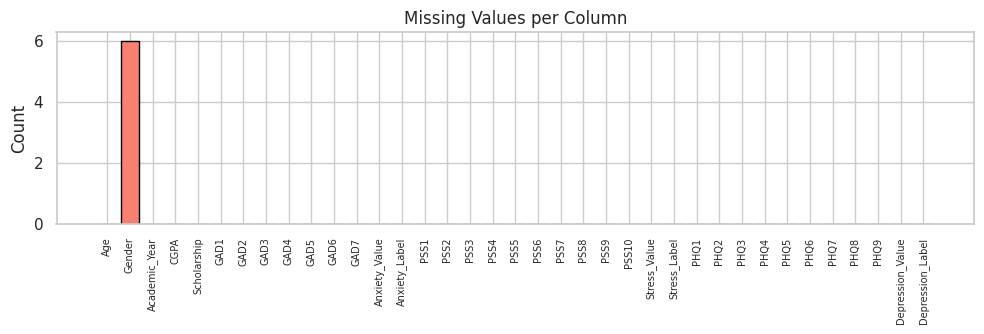

Missing values per column:
Gender    6

Missing after filling : 0
Rows kept             : 1977


In [ ]:
miss = df.isnull().sum()

# Bar chart of missing values per column
plt.figure(figsize=(10, 3.5))
plt.bar(miss.index, miss.values, color='salmon', edgecolor='black')
plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

print("Missing values per column:")
print(miss[miss > 0].to_string())

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0]) #The mode is the most common category.

print(f"\nMissing after filling : {df.isnull().sum().sum()}")
print(f"Rows kept             : {len(df)}")

**Problem 2: Categorical variables**

In [ ]:

df['Age'] = df['Age'].map({v: i for i, v in enumerate(ORDERS['Age'])})
print(f"  {'Age':<16} ordered  -> {dict(zip(ORDERS['Age'], range(len(ORDERS['Age']))))}")

df['Scholarship'] = df['Scholarship'].map({'No': 0, 'Yes': 1})
print(f"  {'Scholarship':<16} binary   -> {{'No': 0, 'Yes': 1}}")

onehot_cols = ['Gender', 'Academic_Year', 'CGPA']
dummies = pd.get_dummies(df[onehot_cols], columns=onehot_cols).astype(int)
df = pd.concat([df.drop(columns=onehot_cols), dummies], axis=1)
for c in onehot_cols:
    made = [d for d in dummies.columns if d.startswith(c + '_')]
    print(f"  {c:<16} one-hot  -> {len(made)} columns")

class_names = {}
for t in TARGETS:
    df[t] = df[t].map({v: i for i, v in enumerate(ORDERS[t])})
    class_names[t] = ORDERS[t]
    print(f"  {t:<16} ordered  -> {dict(zip(ORDERS[t], range(len(ORDERS[t]))))}")

demo = ['Age', 'Scholarship'] + list(dummies.columns)


  Age              ordered  -> {'Below 18': 0, '18-22': 1, '23-26': 2, '27-30': 3, 'Above 30': 4}
  Scholarship      binary   -> {'No': 0, 'Yes': 1}
  Gender           one-hot  -> 3 columns
  Academic_Year    one-hot  -> 5 columns
  CGPA             one-hot  -> 6 columns
  Anxiety_Label    ordered  -> {'Minimal Anxiety': 0, 'Mild Anxiety': 1, 'Moderate Anxiety': 2, 'Severe Anxiety': 3}
  Stress_Label     ordered  -> {'Low Stress': 0, 'Moderate Stress': 1, 'High Perceived Stress': 2}
  Depression_Label ordered  -> {'No Depression': 0, 'Minimal Depression': 1, 'Mild Depression': 2, 'Moderate Depression': 3, 'Moderately Severe Depression': 4, 'Severe Depression': 5}


**Problem 3: Feature scaling**

In [ ]:
print(df[['GAD1', 'Anxiety_Value', 'Stress_Value', 'Depression_Value']]
      .describe().loc[['min', 'max']].T.to_string())

print()
print("Scaling is applied after the split, so no test information leaks into training.")

                  min   max
GAD1              0.0   3.0
Anxiety_Value     0.0  21.0
Stress_Value      0.0  40.0
Depression_Value  0.0  27.0

Scaling is applied after the split, so no test information leaks into training.


---
## 4. Dataset Splitting

80% training / 20% test, stratified so every level keeps its proportion.

In [ ]:
def build_xy(target):
    own = {'Anxiety_Label': anx_items + ['Anxiety_Value'],
           'Stress_Label': str_items + ['Stress_Value'],
           'Depression_Label': dep_items + ['Depression_Value']}[target]
    drop = own + TARGETS
    return df.drop(columns=drop), df[target]

data = {}
for t in TARGETS:
    X, y = build_xy(t)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y)
    scaler = StandardScaler()
    data[t] = {
        'X_train': scaler.fit_transform(X_train),
        'X_test': scaler.transform(X_test),
        'y_train': y_train,
        'y_test': y_test,
        'baseline': y_test.value_counts().max() / len(y_test),
    }
    print(f"{t:<20} features={X.shape[1]:<3} train={len(X_train)} "
          f"test={len(X_test)}  baseline={data[t]['baseline']:.4f}")

Anxiety_Label        features=37  train=1581 test=396  baseline=0.3611
Stress_Label         features=34  train=1581 test=396  baseline=0.6667
Depression_Label     features=35  train=1581 test=396  baseline=0.2500


---
## 5. Model Training & Testing

Three models for each of the three targets: KNN, Logistic Regression and a
Neural Network. K-Means follows as the unsupervised part.

In [ ]:
results = {}

def evaluate(name, model, target):
    d = data[target]
    model.fit(d['X_train'], d['y_train']) #Trains models
    pred = model.predict(d['X_test'])
    results[(target, name)] = {
        'pred': pred,
        'proba': model.predict_proba(d['X_test']),
        'acc': accuracy_score(d['y_test'], pred),
        'prec': precision_score(d['y_test'], pred, average='weighted', zero_division=0),
        'rec': recall_score(d['y_test'], pred, average='weighted', zero_division=0),
        'train_acc': accuracy_score(d['y_train'], model.predict(d['X_train'])),
    }
    r = results[(target, name)]
    print(f"{target:<18}{name:<20} test acc={r['acc']:.4f}  "
          f"train acc={r['train_acc']:.4f}  prec={r['prec']:.4f}  rec={r['rec']:.4f}")

### 5.1 K-Nearest Neighbours (KNN)

Anxiety_Label     KNN                  test acc=0.6136  train acc=0.6540  prec=0.6347  rec=0.6136
Stress_Label      KNN                  test acc=0.7424  train acc=0.7755  prec=0.7525  rec=0.7424
Depression_Label  KNN                  test acc=0.4621  train acc=0.5180  prec=0.4596  rec=0.4621


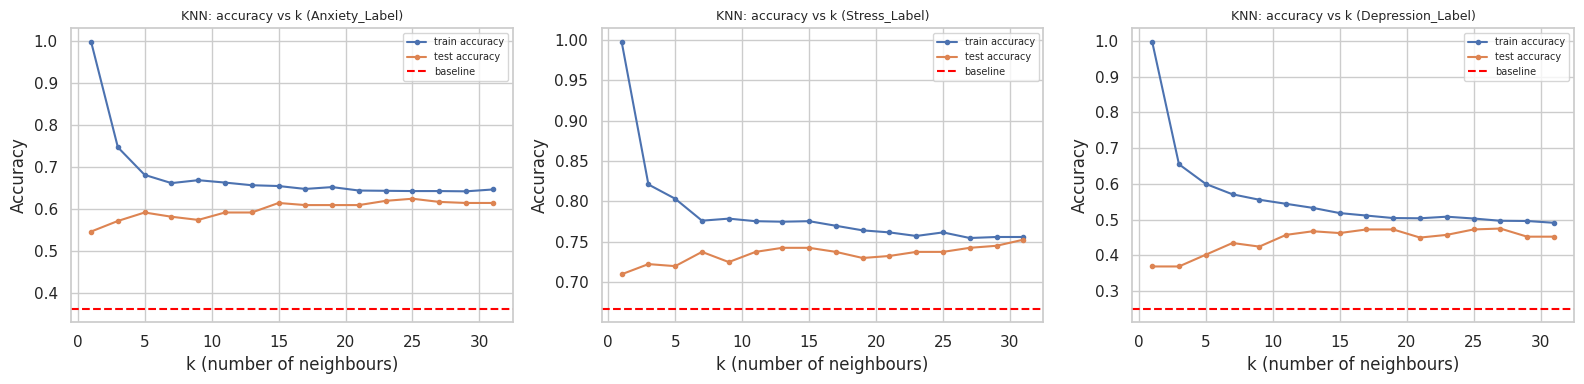

X-axis: number of neighbours
Y-axis: accuracy
Red dashed line: majority baseline


In [ ]:

for t in TARGETS:
    evaluate('KNN', KNeighborsClassifier(n_neighbors=15), t)

ks = range(1, 32, 2)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, t in zip(axes, TARGETS):
    d = data[t]
    train_scores, test_scores = [], []
    for k in ks:
        m = KNeighborsClassifier(n_neighbors=k).fit(d['X_train'], d['y_train'])
        train_scores.append(m.score(d['X_train'], d['y_train']))
        test_scores.append(m.score(d['X_test'], d['y_test']))
    ax.plot(ks, train_scores, marker='o', markersize=3, label='train accuracy')
    ax.plot(ks, test_scores, marker='o', markersize=3, label='test accuracy')
    ax.axhline(d['baseline'], color='red', linestyle='--', label='baseline')
    ax.set_title(f'KNN: accuracy vs k ({t})', fontsize=9)
    ax.set_xlabel('k (number of neighbours)')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

print ("X-axis: number of neighbours")
print ("Y-axis: accuracy")
print ("Red dashed line: majority baseline")

### 5.2 Logistic Regression

In [ ]:
# Fits a linear combination of the features and turns it into a probability for each level.
for t in TARGETS:
    evaluate('Logistic Regression', LogisticRegression(max_iter=1000, random_state=SEED), t)

print()
print("Train and test scores are close together, so this model does not overfit.")

Anxiety_Label     Logistic Regression  test acc=0.6136  train acc=0.6648  prec=0.6074  rec=0.6136
Stress_Label      Logistic Regression  test acc=0.7879  train acc=0.7685  prec=0.7764  rec=0.7879
Depression_Label  Logistic Regression  test acc=0.5303  train acc=0.5174  prec=0.5205  rec=0.5303

Train and test scores are close together, so this model does not overfit.


### 5.3 Neural Network

In [ ]:
def build_nn(n_features, n_classes):
    """Two hidden layers with relu, dropout to limit overfitting, and a
    softmax output giving one probability per level."""
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


histories = {}
for t in TARGETS:
    tf.keras.utils.set_random_seed(SEED)
    d = data[t]
    nn = build_nn(d['X_train'].shape[1], df[t].nunique())
    histories[t] = nn.fit(d['X_train'], d['y_train'], validation_split=0.15,
                          epochs=40, batch_size=32, verbose=0)

    proba = nn.predict(d['X_test'], verbose=0)
    pred = np.argmax(proba, axis=1)
    results[(t, 'Neural Network')] = {
        'pred': pred, 'proba': proba,
        'acc': accuracy_score(d['y_test'], pred),
        'prec': precision_score(d['y_test'], pred, average='weighted', zero_division=0),
        'rec': recall_score(d['y_test'], pred, average='weighted', zero_division=0),
        'train_acc': accuracy_score(
            d['y_train'], np.argmax(nn.predict(d['X_train'], verbose=0), axis=1)),
    }
    r = results[(t, 'Neural Network')]
    print(f"{t:<18}{'Neural Network':<20} test acc={r['acc']:.4f}  "
          f"train acc={r['train_acc']:.4f}  prec={r['prec']:.4f}  rec={r['rec']:.4f}")

Anxiety_Label     Neural Network       test acc=0.6136  train acc=0.7875  prec=0.6135  rec=0.6136
Stress_Label      Neural Network       test acc=0.7525  train acc=0.8564  prec=0.7417  rec=0.7525
Depression_Label  Neural Network       test acc=0.4697  train acc=0.6540  prec=0.4578  rec=0.4697


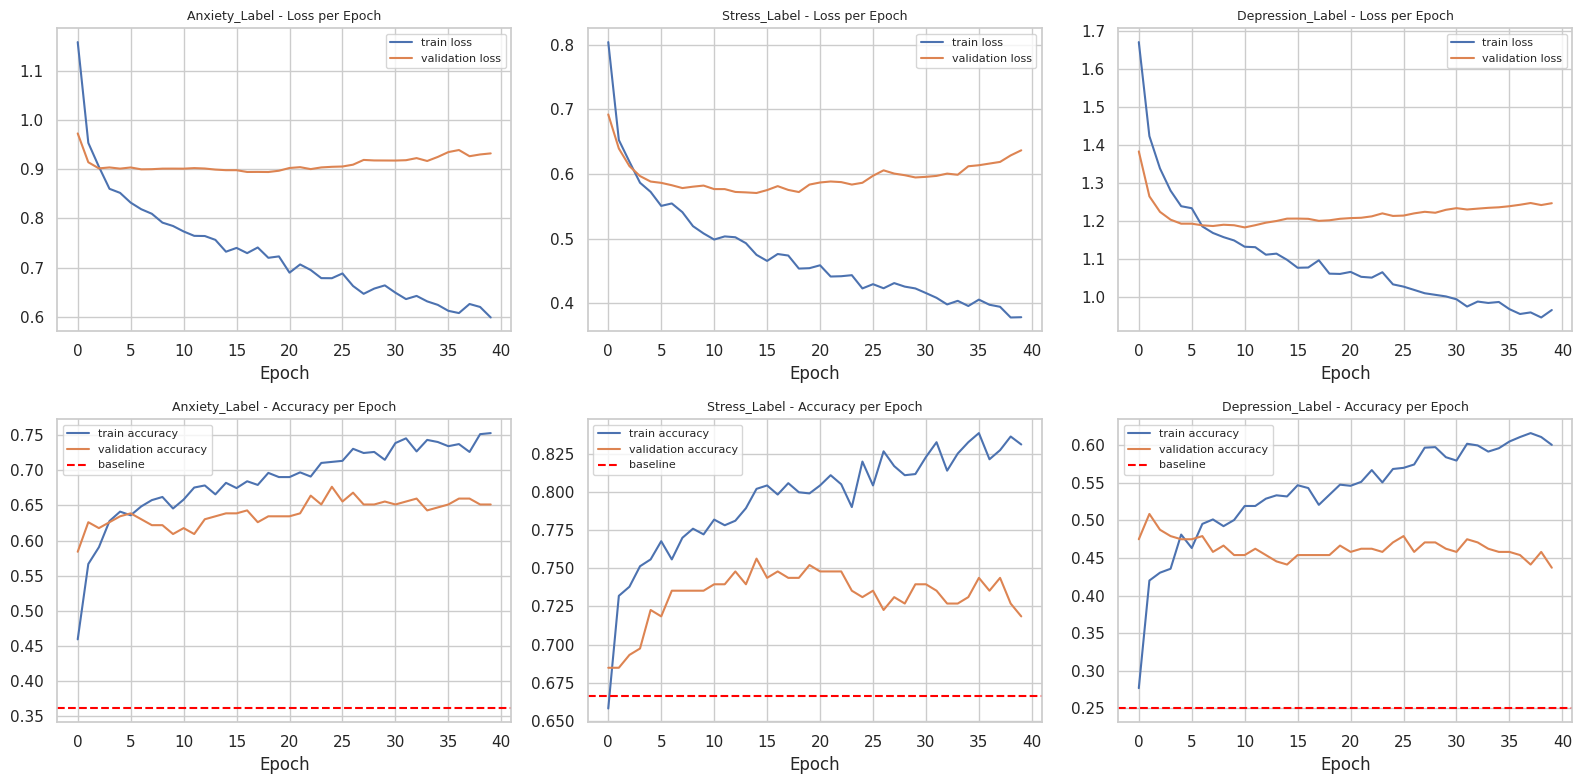

Validation loss drops at first and then flattens while training loss
keeps falling. That growing gap is the network starting to memorise,
which is what the dropout layer is there to limit. Validation accuracy
staying above the red baseline means the network learned something real.


In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for j, t in enumerate(TARGETS):
    h = histories[t]
    # top row: loss
    axes[0, j].plot(h.history['loss'], label='train loss')
    axes[0, j].plot(h.history['val_loss'], label='validation loss')
    axes[0, j].set_title(f'{t} - Loss per Epoch', fontsize=9)
    axes[0, j].set_xlabel('Epoch')
    axes[0, j].legend(fontsize=8)
    # bottom row: accuracy
    axes[1, j].plot(h.history['accuracy'], label='train accuracy')
    axes[1, j].plot(h.history['val_accuracy'], label='validation accuracy')
    axes[1, j].axhline(data[t]['baseline'], color='red', linestyle='--', label='baseline')
    axes[1, j].set_title(f'{t} - Accuracy per Epoch', fontsize=9)
    axes[1, j].set_xlabel('Epoch')
    axes[1, j].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Validation loss drops at first and then flattens while training loss")
print("keeps falling. That growing gap is the network starting to memorise,")
print("which is what the dropout layer is there to limit. Validation accuracy")
print("staying above the red baseline means the network learned something real.")

### 5.4 K-Means (Unsupervised)

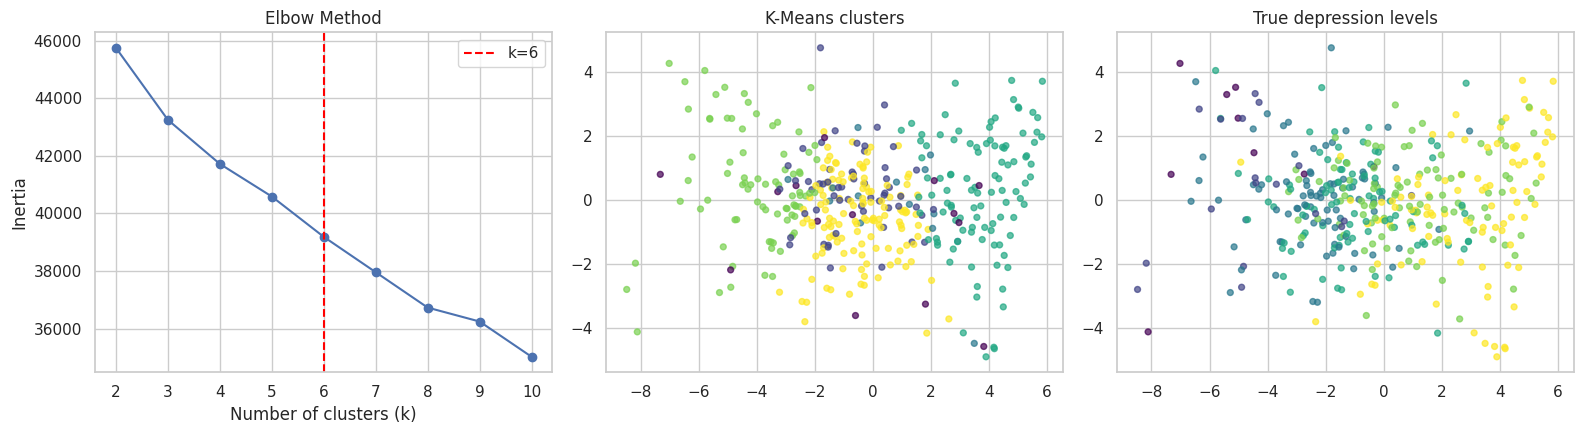

Adjusted Rand Index = 0.1296
ARI is 1.0 for a perfect match and 0.0 for random agreement. A low value
means the natural groups do not line up with the depression levels,
because clustering follows overall similarity, not one chosen label.


In [ ]:
# Unsupervised: ignore the labels and see whether students group naturally. We cluster on the depression feature set.
d = data['Depression_Label']
k_classes = df['Depression_Label'].nunique()

inertias = [KMeans(n_clusters=k, random_state=SEED, n_init=10)
            .fit(d['X_train']).inertia_ for k in range(2, 11)]

km = KMeans(n_clusters=k_classes, random_state=SEED, n_init=10).fit(d['X_train'])
clusters = km.predict(d['X_test'])

pts = PCA(n_components=2, random_state=SEED).fit(d['X_train']).transform(d['X_test'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(range(2, 11), inertias, marker='o')
axes[0].axvline(k_classes, color='red', linestyle='--', label=f'k={k_classes}')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].legend()

axes[1].scatter(pts[:, 0], pts[:, 1], c=clusters, cmap='viridis', alpha=0.7, s=18)
axes[1].set_title('K-Means clusters')
axes[2].scatter(pts[:, 0], pts[:, 1], c=d['y_test'], cmap='viridis', alpha=0.7, s=18)
axes[2].set_title('True depression levels')
plt.tight_layout()
plt.show()

print(f"Adjusted Rand Index = {adjusted_rand_score(d['y_test'], clusters):.4f}")
print("ARI is 1.0 for a perfect match and 0.0 for random agreement. A low value")
print("means the natural groups do not line up with the depression levels,")
print("because clustering follows overall similarity, not one chosen label.")

---
## 6. Model Comparison

          Target               Model  Accuracy  Precision  Recall  Baseline
   Anxiety_Label                 KNN    0.6136     0.6347  0.6136    0.3611
    Stress_Label                 KNN    0.7424     0.7525  0.7424    0.6667
Depression_Label                 KNN    0.4621     0.4596  0.4621    0.2500
   Anxiety_Label Logistic Regression    0.6136     0.6074  0.6136    0.3611
    Stress_Label Logistic Regression    0.7879     0.7764  0.7879    0.6667
Depression_Label Logistic Regression    0.5303     0.5205  0.5303    0.2500
   Anxiety_Label      Neural Network    0.6136     0.6135  0.6136    0.3611
    Stress_Label      Neural Network    0.7525     0.7417  0.7525    0.6667
Depression_Label      Neural Network    0.4697     0.4578  0.4697    0.2500


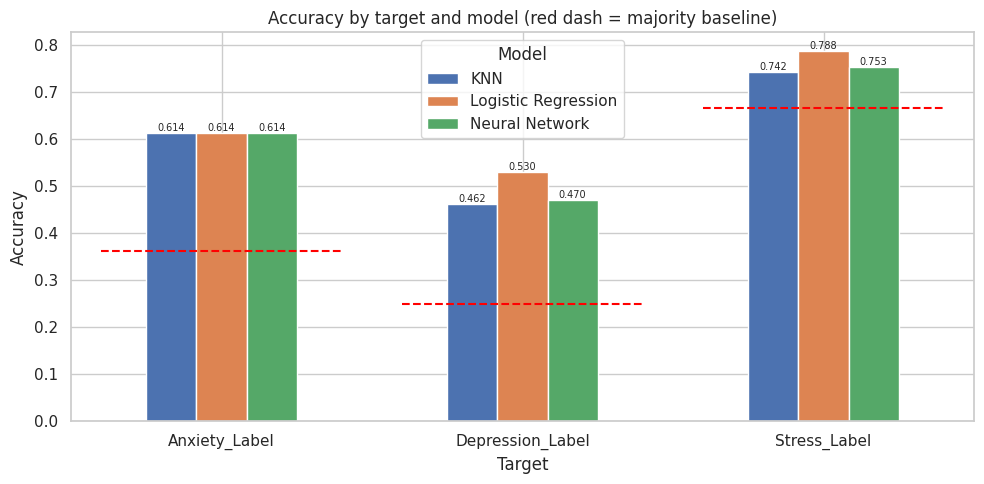

In [ ]:
summary = pd.DataFrame([
    {'Target': t, 'Model': m, 'Accuracy': r['acc'], 'Precision': r['prec'],
     'Recall': r['rec'], 'Baseline': data[t]['baseline']}
    for (t, m), r in results.items()
])
print(summary.round(4).to_string(index=False))

pivot = summary.pivot(index='Target', columns='Model', values='Accuracy')
ax = pivot.plot(kind='bar', figsize=(10, 5), rot=0)
for i, t in enumerate(pivot.index):
    ax.hlines(data[t]['baseline'], i - 0.4, i + 0.4, color='red', linestyle='--')
ax.set_title('Accuracy by target and model (red dash = majority baseline)')
ax.set_ylabel('Accuracy')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', fontsize=7)
plt.tight_layout()
plt.show()

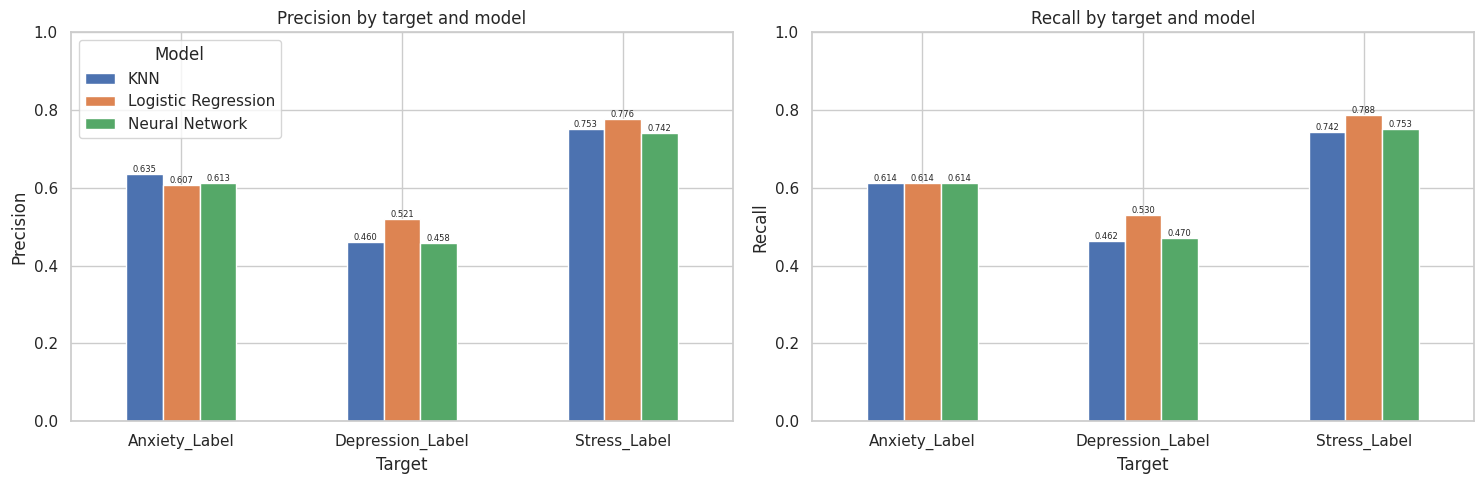

In [ ]:
# Precision and recall comparison for every model on every target
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, metric in zip(axes, ['Precision', 'Recall']):
    p = summary.pivot(index='Target', columns='Model', values=metric)
    p.plot(kind='bar', ax=ax, rot=0, legend=(metric == 'Precision'))
    ax.set_title(f'{metric} by target and model')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    for c in ax.containers:
        ax.bar_label(c, fmt='%.3f', fontsize=6)

plt.tight_layout()
plt.show()


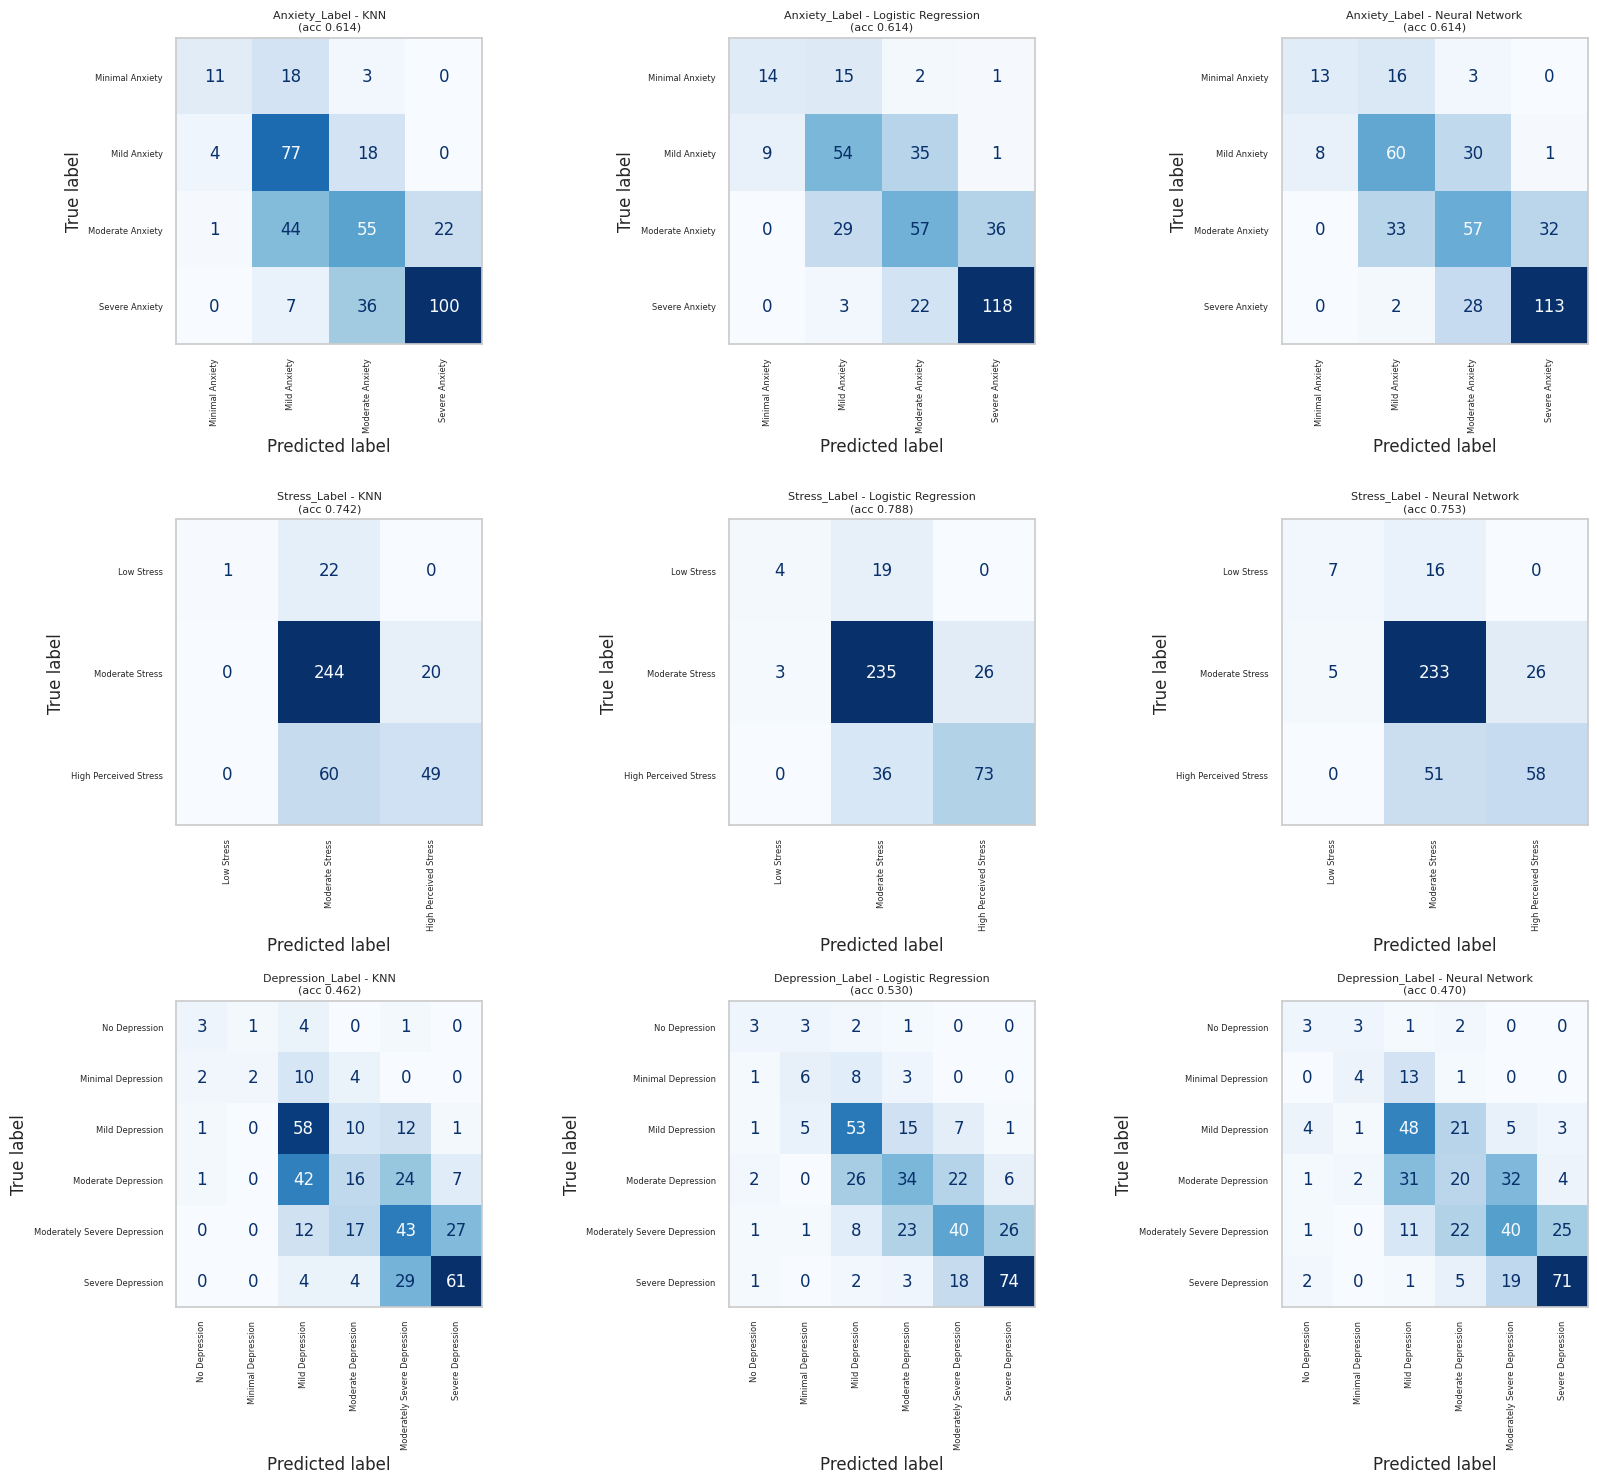

Best model per target (by accuracy):
  Anxiety_Label        KNN                    acc 0.6136
  Stress_Label         Logistic Regression    acc 0.7879
  Depression_Label     Logistic Regression    acc 0.5303

A strong diagonal means correct predictions.


In [ ]:
# Confusion matrix for EVERY model on EVERY target (3 models x 3 targets). Rows are the true level, columns are the predicted level.
MODELS = ['KNN', 'Logistic Regression', 'Neural Network']
fig, axes = plt.subplots(3, 3, figsize=(17, 15))

for row, t in enumerate(TARGETS):
    for col, m in enumerate(MODELS):
        ax = axes[row, col]
        cm = confusion_matrix(data[t]['y_test'], results[(t, m)]['pred'])
        ConfusionMatrixDisplay(cm, display_labels=class_names[t]).plot(
            ax=ax, cmap='Blues', colorbar=False, xticks_rotation=90)
        ax.set_title(f"{t} - {m}\n(acc {results[(t, m)]['acc']:.3f})", fontsize=8)
        ax.tick_params(labelsize=6)
        ax.grid(False)

plt.tight_layout()
plt.show()

best_models = {t: max(MODELS, key=lambda m: results[(t, m)]['acc']) for t in TARGETS}
print("Best model per target (by accuracy):")
for t, m in best_models.items():
    print(f"  {t:<20} {m:<22} acc {results[(t, m)]['acc']:.4f}")

print()
print("A strong diagonal means correct predictions.")

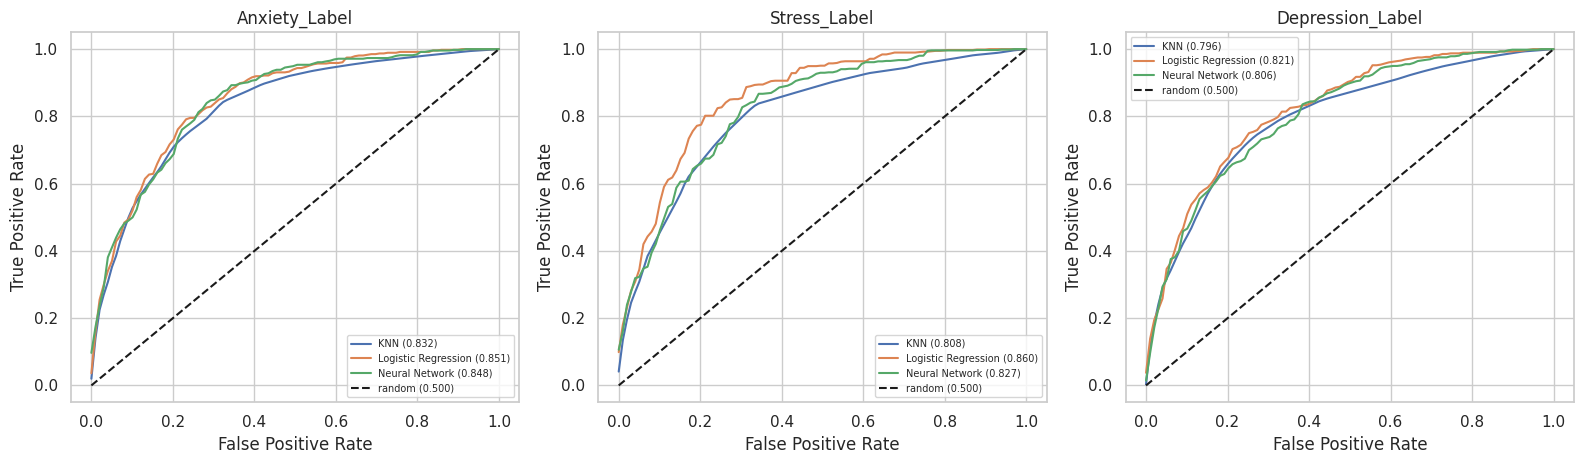

AUC of 0.5 means random guessing. The further above 0.5, the better the
model separates the levels.

--- Anxiety_Label: KNN ---
                  precision    recall  f1-score   support

 Minimal Anxiety      0.688     0.344     0.458        32
    Mild Anxiety      0.527     0.778     0.629        99
Moderate Anxiety      0.491     0.451     0.470       122
  Severe Anxiety      0.820     0.699     0.755       143

        accuracy                          0.614       396
       macro avg      0.631     0.568     0.578       396
    weighted avg      0.635     0.614     0.612       396

--- Stress_Label: Logistic Regression ---
                       precision    recall  f1-score   support

           Low Stress      0.571     0.174     0.267        23
      Moderate Stress      0.810     0.890     0.848       264
High Perceived Stress      0.737     0.670     0.702       109

             accuracy                          0.788       396
            macro avg      0.706     0.578    

In [ ]:
# ROC is a binary idea, so for multi-class we use one-vs-rest: each level in turn is treated as positive, and the curves are averaged into one per model.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
grid = np.linspace(0, 1, 100)

for ax, t in zip(axes, TARGETS):
    classes = sorted(df[t].unique())
    y_bin = label_binarize(data[t]['y_test'], classes=classes)
    for m in ['KNN', 'Logistic Regression', 'Neural Network']:
        proba = results[(t, m)]['proba']
        tprs = [np.interp(grid, *roc_curve(y_bin[:, i], proba[:, i])[:2])
                for i in range(len(classes))]
        auc = roc_auc_score(data[t]['y_test'], proba, multi_class='ovr', average='macro')
        ax.plot(grid, np.mean(tprs, axis=0), label=f'{m} ({auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', label='random (0.500)')
    ax.set_title(t)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

print("AUC of 0.5 means random guessing. The further above 0.5, the better the")
print("model separates the levels.")
print()
for t in TARGETS:
    print(f"--- {t}: {best_models[t]} ---")
    print(classification_report(data[t]['y_test'], results[(t, best_models[t])]['pred'],
                                target_names=class_names[t], digits=3, zero_division=0))

## 7. Conclusion

**Results:**

* **Anxiety:** All three models achieved **0.614 accuracy**, exceeding the **0.361 baseline**.
* **Stress:** Logistic Regression performed best with **0.788 accuracy**, exceeding the **0.667 baseline**.
* **Depression:** Logistic Regression performed best with **0.530 accuracy**, exceeding the **0.250 baseline**.
* Logistic Regression also achieved the highest AUC for anxiety (**0.851**), stress (**0.860**), and depression (**0.821**).

**Reasoning for the Results:**

The models performed better than the baselines because anxiety, stress, and depression are related. The correlation heatmap and EDA graphs showed that higher anxiety and stress scores were generally associated with higher depression levels. However, K-Means produced a low ARI of **0.130**, meaning the depression classes did not form clearly separated natural clusters.

**Comments:**

Logistic Regression was the most consistent model. KNN performed reasonably and tied for the best anxiety accuracy, while the Neural Network showed overfitting because its training accuracy was considerably higher than its test accuracy. Since the classes were imbalanced, precision, recall, confusion matrices, and ROC-AUC were also considered instead of relying only on accuracy.

**Challenges:**

* Six missing Gender values were replaced with the most frequent category.
* Categorical features required appropriate ordinal or one-hot encoding.
* Each target has own questions, total score, and all label columns had to be removed to prevent data leakage.
* Rare classes were more difficult to predict because of class imbalance.
